## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
fold_id = 3
mod = f"Grid_Optimization_Fold_{fold_id}"

gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test(5)

x_train, y_train, x_test, y_test = gallstone_dataset.fold_split[fold_id]

features_size = x_train.shape[1]

In [3]:
best_lambda_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [4]:
abc_r_elm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [5]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 003 complete | Duration: 0.0988s | Scout Triggers: 3 | Best Fitness: 0.769501

Running simulation for Seed: 162...
Iteration 003 complete | Duration: 0.2833s | Scout Triggers: 4 | Best Fitness: 0.752114

Running simulation for Seed: 163...
Iteration 003 complete | Duration: 0.0851s | Scout Triggers: 2 | Best Fitness: 0.762859

Running simulation for Seed: 164...
Iteration 003 complete | Duration: 0.0846s | Scout Triggers: 4 | Best Fitness: 0.754481

Running simulation for Seed: 165...
Iteration 003 complete | Duration: 0.0948s | Scout Triggers: 3 | Best Fitness: 0.779289

Running simulation for Seed: 166...
Iteration 003 complete | Duration: 0.1035s | Scout Triggers: 5 | Best Fitness: 0.762538

Running simulation for Seed: 167...
Iteration 003 complete | Duration: 0.1037s | Scout Triggers: 5 | Best Fitness: 0.756702

Running simulation for Seed: 168...
Iteration 003 complete | Duration: 0.0874s | Scout Triggers: 3 | Best Fitness: 0.756790


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.684896,0.716592,0.612500,0.662306,0.757292,0.659662,0.630380,0.684896,0.374300,175.500000
std,0.027855,0.031755,0.046857,0.028014,0.034510,0.035173,0.042136,0.027855,0.055418,8.803408
min,0.640625,0.655172,0.531250,0.615385,0.687500,0.596491,0.555556,0.640625,0.282494,161.000000
25%,0.660156,0.694231,0.570312,0.642534,0.750000,0.635714,0.595353,0.660156,0.328379,168.250000
50%,0.687500,0.722069,0.625000,0.662281,0.750000,0.661202,0.634927,0.687500,0.379868,175.500000
75%,0.703125,0.733333,0.656250,0.685714,0.781250,0.688525,0.668790,0.703125,0.408047,182.750000
max,0.734375,0.777778,0.687500,0.705882,0.812500,0.711864,0.696203,0.734375,0.474579,190.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Fold_3_MCC.png


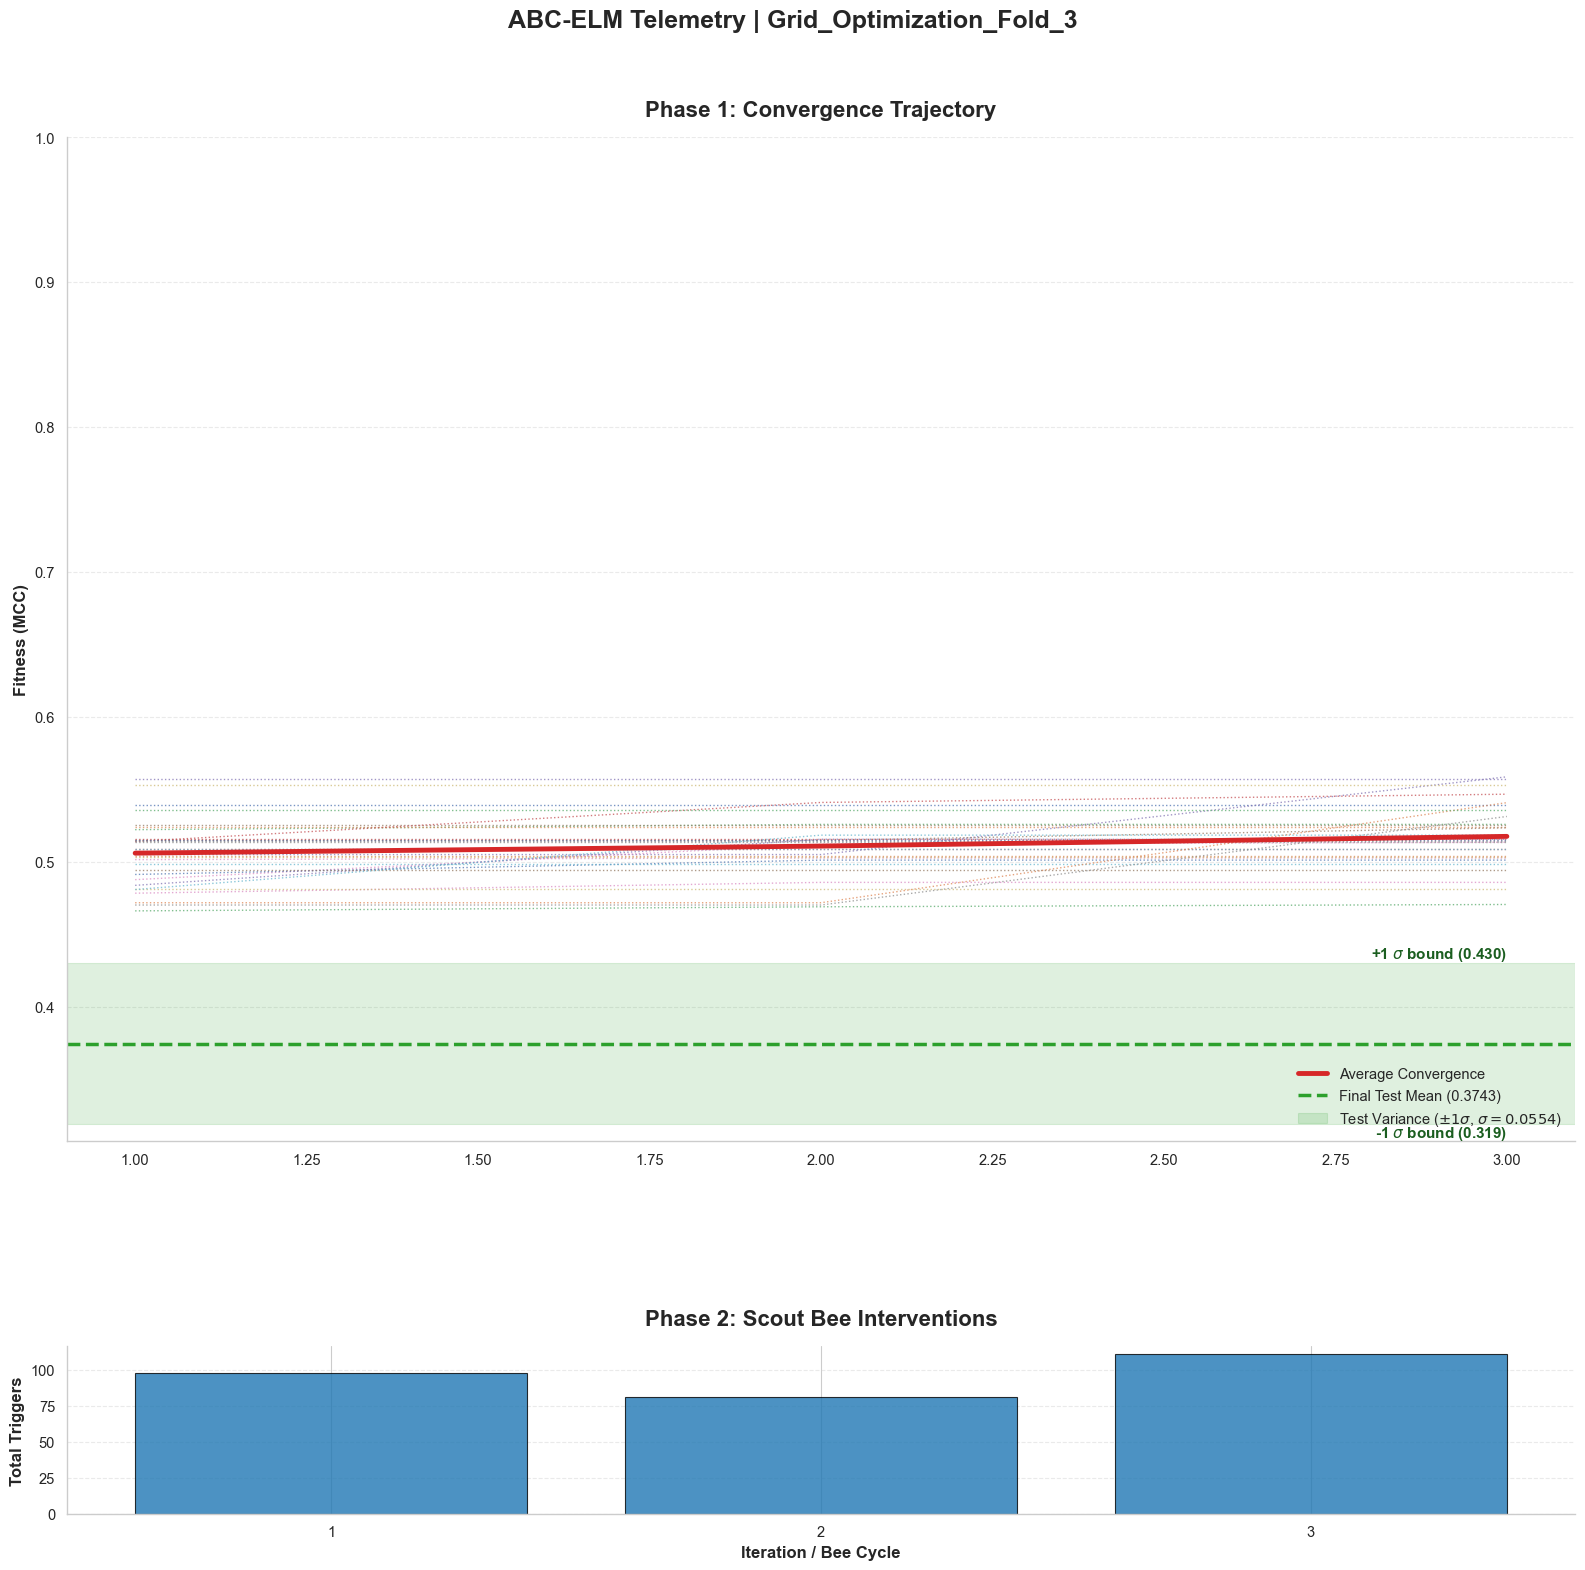

In [6]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [7]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_3_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_3_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_3_Scout_History.csv
